In [1]:
import torch
print("MPS available:", torch.backends.mps.is_available())
print("MPS built:", torch.backends.mps.is_built())

MPS available: True
MPS built: True


Matplotlib is building the font cache; this may take a moment.


Parasitized: 13779 images
  sample size: (112, 115), mode: RGB
Uninfected: 13779 images
  sample size: (115, 127), mode: RGB


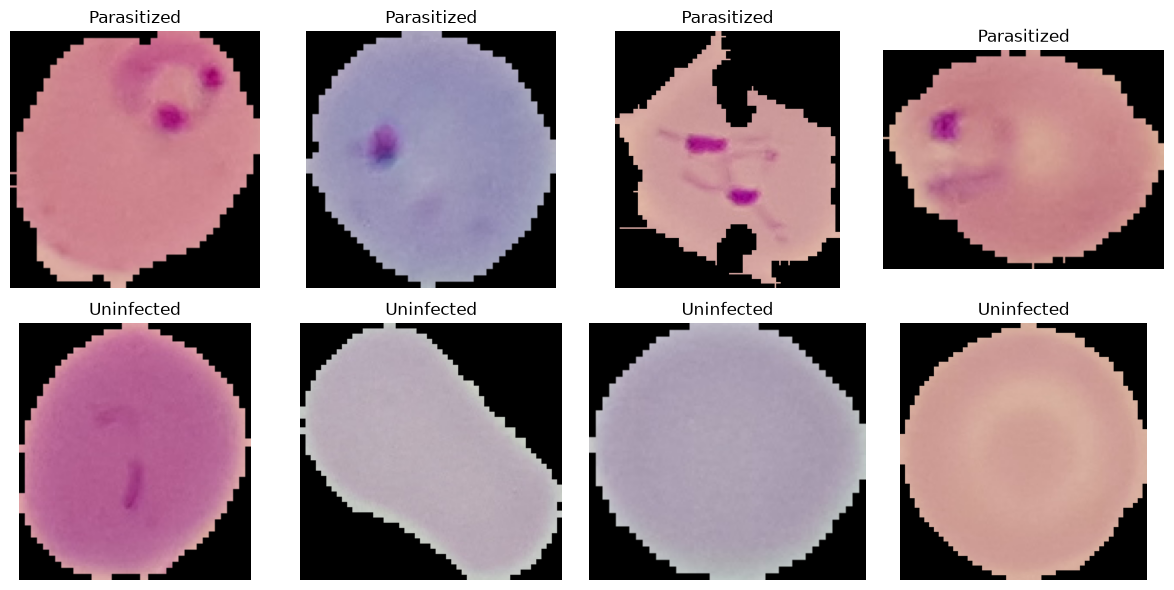

In [2]:
import os
from PIL import Image
import matplotlib.pyplot as plt

data_dir = "cell_images"
classes = ["Parasitized", "Uninfected"]

for c in classes:
    files = os.listdir(os.path.join(data_dir, c))
    files = [f for f in files if f.endswith(".png")]
    print(f"{c}: {len(files)} images")

    # look at one sample image's size
    sample = Image.open(os.path.join(data_dir, c, files[0]))
    print(f"  sample size: {sample.size}, mode: {sample.mode}")

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, c in enumerate(classes):
    files = os.listdir(os.path.join(data_dir, c))[:4]
    for j, f in enumerate(files):
        img = Image.open(os.path.join(data_dir, c, f))
        axes[i, j].imshow(img)
        axes[i, j].set_title(c)
        axes[i, j].axis("off")
plt.tight_layout()
plt.show()

In [3]:
import random
from sklearn.model_selection import train_test_split

random.seed(42)
N_PER_CLASS = 3000 

def sample_paths(class_name, n):
    folder = os.path.join(data_dir, class_name)
    files = [f for f in os.listdir(folder) if f.endswith(".png")]
    chosen = random.sample(files, n)
    return [os.path.join(folder, f) for f in chosen]

parasitized_paths = sample_paths("Parasitized", N_PER_CLASS)
uninfected_paths = sample_paths("Uninfected", N_PER_CLASS)

paths = parasitized_paths + uninfected_paths
labels = [1] * N_PER_CLASS + [0] * N_PER_CLASS  # 1 = parasitized, 0 = uninfected


train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths, labels, test_size=0.3, stratify=labels, random_state=42
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

print(f"Train: {len(train_paths)}, Val: {len(val_paths)}, Test: {len(test_paths)}")



Train: 4200, Val: 900, Test: 900


In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

IMG_SIZE = 64  # small, since cells are already small — keeps training fast

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),  # converts to [0,1] range automatically, and reshapes to (C,H,W)
])

class MalariaDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label

train_ds = MalariaDataset(train_paths, train_labels, transform)
val_ds = MalariaDataset(val_paths, val_labels, transform)
test_ds = MalariaDataset(test_paths, test_labels, transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
import torch.nn as nn
import torch.optim as optim

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

class MalariaCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 1)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # 64x64 -> 32x32
        x = self.pool(self.relu(self.conv2(x)))  # 32x32 -> 16x16
        x = self.pool(self.relu(self.conv3(x)))  # 16x16 -> 8x8
        x = x.view(x.size(0), -1)                # flatten
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x.squeeze(1)  # raw logits — no sigmoid here, see below

model = MalariaCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Using device: mps


In [7]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total

EPOCHS = 15
for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    print(f"Epoch {epoch+1}/{EPOCHS} - train_loss: {train_loss:.4f} acc: {train_acc:.4f} - val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}")

Epoch 1/15 - train_loss: 0.6835 acc: 0.5450 - val_loss: 0.6252 val_acc: 0.6756
Epoch 2/15 - train_loss: 0.6016 acc: 0.6843 - val_loss: 0.4978 val_acc: 0.7822
Epoch 3/15 - train_loss: 0.3838 acc: 0.8252 - val_loss: 0.2310 val_acc: 0.9211
Epoch 4/15 - train_loss: 0.2020 acc: 0.9305 - val_loss: 0.1885 val_acc: 0.9378
Epoch 5/15 - train_loss: 0.1693 acc: 0.9445 - val_loss: 0.1955 val_acc: 0.9267
Epoch 6/15 - train_loss: 0.1472 acc: 0.9505 - val_loss: 0.1732 val_acc: 0.9422
Epoch 7/15 - train_loss: 0.1438 acc: 0.9531 - val_loss: 0.1537 val_acc: 0.9444
Epoch 8/15 - train_loss: 0.1236 acc: 0.9571 - val_loss: 0.1609 val_acc: 0.9478
Epoch 9/15 - train_loss: 0.1181 acc: 0.9581 - val_loss: 0.1603 val_acc: 0.9489
Epoch 10/15 - train_loss: 0.1127 acc: 0.9602 - val_loss: 0.1462 val_acc: 0.9444
Epoch 11/15 - train_loss: 0.1003 acc: 0.9657 - val_loss: 0.1616 val_acc: 0.9433
Epoch 12/15 - train_loss: 0.0987 acc: 0.9650 - val_loss: 0.1695 val_acc: 0.9400
Epoch 13/15 - train_loss: 0.0868 acc: 0.9693 - va